TAREA 1: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

In [2]:
# Lee imagen de archivo
img = cv2.imread("mandril.jpg")

# Si hay lectura correcta
if img is not None:
    # Muestra dimensiones
    print(img.shape)

    # Recordar que OpenCV lee las imágenes almacenando en formato BGR, por lo que convertimos para visualizr de forma correcta a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
else:
    print("Imagen no encontrada")

(512, 512, 3)


In [3]:
# Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gris.shape)


(512, 512)


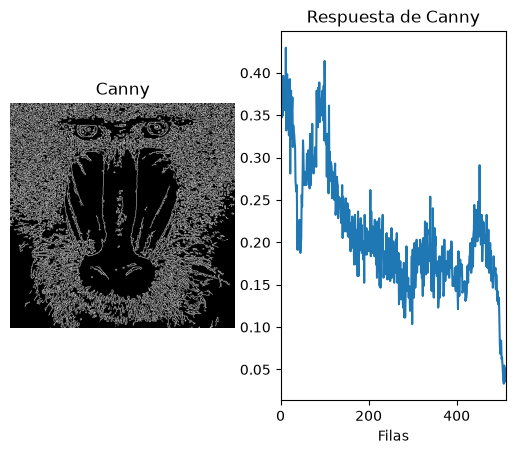

In [4]:
# Obtiene contornos con el operador de Canny
# Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 100, 200)  # prueba a jugar con umbrales (entre 0 y 255)

# Cuenta el número de píxeles blancos (255) por fila
white_pixels_per_row = cv2.reduce(canny, 255, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Porcentaje por fila
percentage_per_row = white_pixels_per_row / (255 * canny.shape[1])

# Muestra dicha cuenta gráficamente
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(percentage_per_row)
# Rango en x definido por filas
plt.xlim([0, canny.shape[0]])

plt.show()

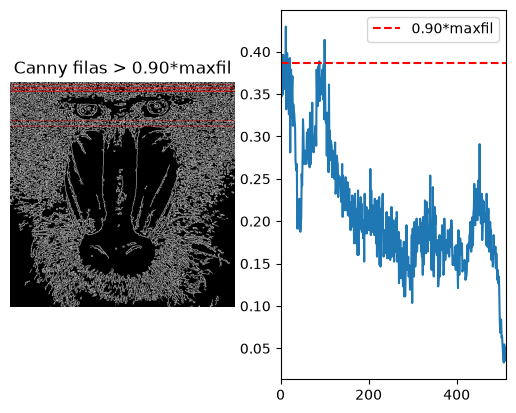

In [5]:
maxfil = np.max(white_pixels_per_row)
umbral = 0.90 * maxfil
filas_sel = np.where(white_pixels_per_row.flatten() > umbral)[0]

# Imagen de Canny en color (BGR) para poder dibujar en rojo
canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
for f in filas_sel:
    cv2.line(canny_color, (0, int(f)), (canny.shape[1] - 1, int(f)), (0, 0, 255), 1)

# Muestra la imagen resaltada y el plot con el umbral
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny filas > 0.90*maxfil")
plt.imshow(cv2.cvtColor(canny_color, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.ylabel("% píxeles")
plt.plot(percentage_per_row)
plt.axhline(umbral / (255 * canny.shape[1]), color="r", linestyle="--", label="0.90*maxfil")
# Rango en x definido por filas
plt.xlim([0, canny.shape[0]])
plt.legend()

plt.show()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

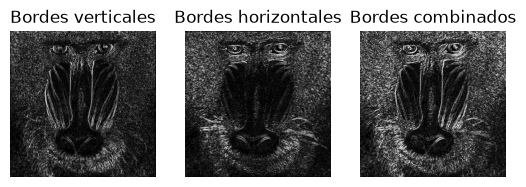

In [6]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

#Muestra ambos resultados
plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('Bordes verticales')
#Verticales
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobelx), cmap='gray') 
#plt.imshow(sobelx, cmap='gray') #Prueba sin convertir escala

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('Bordes horizontales')
#Horizontales
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobely), cmap='gray') 
#plt.imshow(sobelx, cmap='gray') #Prueba sin convertir escala

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Bordes combinados')
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobel), cmap='gray') 
#plt.imshow(sobel, cmap='gray') #Prueba sin convertir escala
plt.show()

Observa que visualizar la imagen resultado de Sobel directamente como escala de grises produce un resultado diferente. Ha sido necesario convertir a datos de tipo byte. La siguiente celda muestra dos variantes de conversión, con OpenCV y numpy, evidenciando alguna diferencia, además de los valores antes y tras escalar a 8 bits

Tipo de datos, valor mínimo y máximo en sobel: float64, -594.0, 570.0
Tipo de datos, valor mínimo y máximo en sobel8: uint8, 0, 255
Tipo de datos, valor mínimo y máximo en sobel8np: uint8, 0, 254


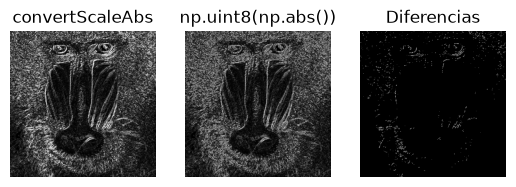

In [7]:
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel: {sobel.dtype}, {np.min(sobel)}, {np.max(sobel)}")

# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8: {sobel8.dtype}, {np.min(sobel8)}, {np.max(sobel8)}")

# Conversión a byte con numpy
sobel8np = np.uint8(np.abs(sobel))
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8np: {sobel8np.dtype}, {np.min(sobel8np)}, {np.max(sobel8np)}")

plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('convertScaleAbs')
plt.imshow(sobel8, cmap='gray') 

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('np.uint8(np.abs())')
plt.imshow(sobel8np, cmap='gray') 

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Diferencias')
plt.imshow(cv2.absdiff(sobel8,sobel8np), cmap='gray') 

plt.show()

A continución, se procederá a umbralizar la imagen resultante de Sobel.

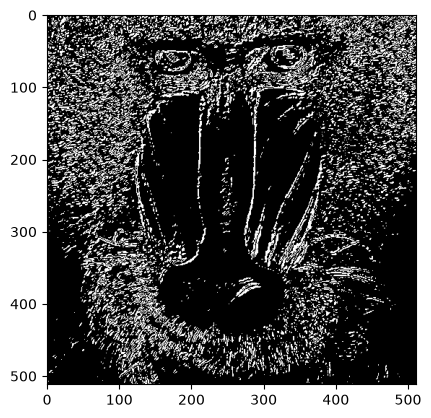

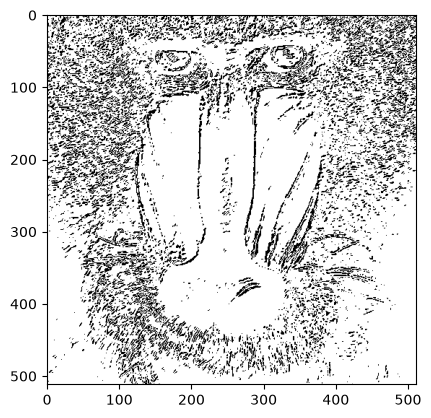

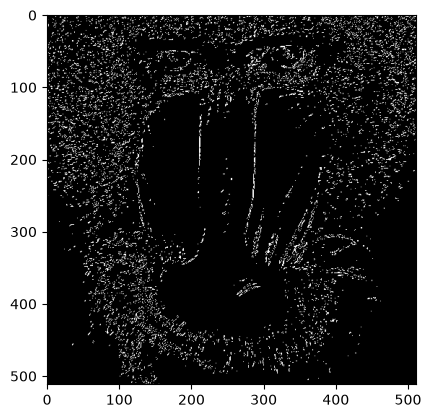

In [13]:
#Define valor umbral
valorUmbral = 100 #Prueba otros valores
#Obtiene imagen umbralizada para dicho valor definido
_, sobelUmbralizado = cv2.threshold(sobel8np, valorUmbral, 255, cv2.THRESH_BINARY)
#Muestra resultado
plt.imshow(sobelUmbralizado, cmap='gray')
plt.show()

#El umbralizado inverso, los valores menores que el umbral se muestran en blanco
_, sobelUmbralizadoInverso = cv2.threshold(sobel8np, valorUmbral, 255, cv2.THRESH_BINARY_INV)
#Muestra resultado
plt.imshow(sobelUmbralizadoInverso, cmap='gray')
plt.show()

#Valores en rango determinado por dos umbrales
imagenEnRango = cv2.inRange(sobel8np, 150, 200)
#Muestra resultado
plt.imshow(imagenEnRango, cmap='gray')
plt.show()

Conteo columnas por Sobel

(0.0, 512.0)

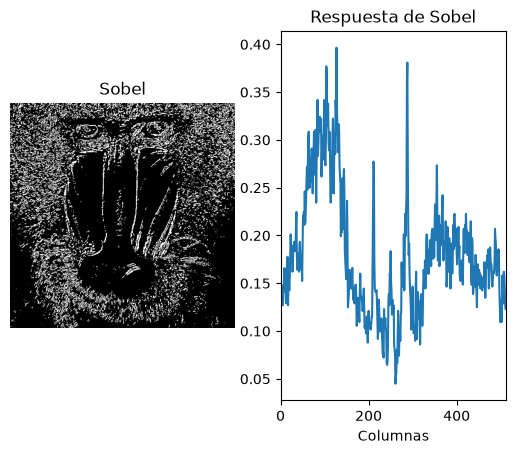

In [15]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
col_counts = cv2.reduce(sobelUmbralizado, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
cols = col_counts[0] / (255 * sobelUmbralizado.shape[0])

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel")
plt.imshow(sobelUmbralizado, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Sobel")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)
#Rango en x definido por las columnas
plt.xlim([0, sobelUmbralizado.shape[1]])

Conteo de filas por Sobel

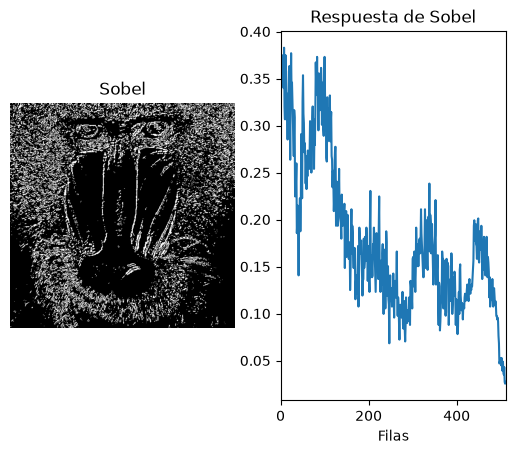

In [16]:
# Obtiene contornos con el operador de Canny
# Parámetros: imagen de entrada, umbral inferior, umbral superior
#canny = cv2.Canny(gris, 100, 200)  # prueba a jugar con umbrales (entre 0 y 255)

# Cuenta el número de píxeles blancos (255) por fila
white_pixels_per_row = cv2.reduce(sobelUmbralizado, 255, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Porcentaje por fila
percentage_per_row = white_pixels_per_row / (255 * sobelUmbralizado.shape[1])

# Muestra dicha cuenta gráficamente
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel")
plt.imshow(sobelUmbralizado, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Respuesta de Sobel")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(percentage_per_row)
# Rango en x definido por filas
plt.xlim([0, sobelUmbralizado.shape[0]])

plt.show()

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.